# Task 4 — Statistical Modeling & Risk-Based Pricing

This notebook develops predictive models for insurance risk analytics and premium optimization.

The analysis focuses on two objectives:

1. Claim Severity Prediction  
   Predict the expected claim amount (`TotalClaims`) for policies that experienced claims.

2. Premium Optimization Framework  
   Estimate risk-adjusted premiums using:
   
   Premium = Probability of Claim × Predicted Severity + Expense Loading + Profit Margin

Three machine learning algorithms are evaluated:

- Linear Regression
- Random Forest
- XGBoost

Model performance is assessed using regression and classification metrics, followed by SHAP-based feature interpretability to explain business drivers of insurance risk.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import shap

from src.data_loader import load_data
from src.modeling import (
    evaluate_regression_model,
    create_classification_target
)

sns.set_style("whitegrid")

In [2]:
df = load_data("../data/insurance_data.csv")

df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


## Data Preparation

The dataset was prepared for predictive modeling through preprocessing and feature engineering.

The preparation stage included:

- Handling missing values
- Creating additional predictive features
- Encoding categorical variables
- Splitting the data into training and testing sets

These steps ensure the models can learn meaningful risk patterns while avoiding data leakage.

In [3]:
df.isnull().sum()

CustomerID             0
Age                    0
Gender                 0
Province               0
VehicleType            0
AnnualIncome           0
RiskScore              0
AnnualPremium          0
Deductible             0
NCD                    0
PastClaims             0
Claimed                0
ClaimAmount            0
TotalPremium           0
TotalClaims            0
CoverType              0
AutoMake               0
VehicleModel           0
CustomValueEstimate    0
ZipCode                0
TransactionDate        0
dtype: int64

The dataset contains no missing values across all features. Therefore, no imputation or row removal was required before modeling.

In [17]:
# Convert date column
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

# Extract temporal features
df["TransactionMonth"] = df["TransactionDate"].dt.month
df["TransactionYear"] = df["TransactionDate"].dt.year

# Create profitability feature
df["Margin"] = df["TotalPremium"] - df["TotalClaims"]

# Create binary claim target
df["HasClaim"] = np.where(df["TotalClaims"] > 0, 1, 0)

# Customer age grouping
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[18, 30, 45, 60, 80],
    labels=["Young", "Adult", "MiddleAge", "Senior"]
)

# Income category feature
df["IncomeBand"] = pd.qcut(
    df["AnnualIncome"],
    q=4,
    labels=["Low", "Medium", "High", "VeryHigh"]
)

# Vehicle value ratio
df["PremiumToValueRatio"] = (
    df["TotalPremium"] / df["CustomValueEstimate"]
)

# Claim history intensity
df["ClaimsPerPastClaim"] = (
    df["TotalClaims"] / (df["PastClaims"] + 1)
)

Several additional variables were engineered to improve predictive performance.

- TransactionMonth captures possible seasonal claim patterns.
- Margin measures profitability at policy level.
- HasClaim converts claim occurrence into a binary classification target.

These features support both severity prediction and premium optimization modeling.

In [5]:
claims_df = df[df["TotalClaims"] > 0].copy()

In [6]:
features = [
    "Age",
    "Gender",
    "Province",
    "VehicleType",
    "AnnualIncome",
    "RiskScore",
    "Deductible",
    "PastClaims",
    "CoverType",
    "AutoMake",
    "CustomValueEstimate",
    "TransactionMonth"
]

target = "TotalClaims"

In [7]:
X = claims_df[features]
y = claims_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
categorical_cols = [
    "Gender",
    "Province",
    "VehicleType",
    "CoverType",
    "AutoMake"
]

numeric_cols = [
    "Age",
    "AnnualIncome",
    "RiskScore",
    "Deductible",
    "PastClaims",
    "CustomValueEstimate",
    "TransactionMonth"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

# Modeling

Three machine learning algorithms were developed and evaluated for claim severity prediction:

- Linear Regression
- Random Forest Regressor
- XGBoost Regressor

These models were selected to compare:
- Linear statistical relationships
- Non-linear ensemble learning
- Advanced gradient boosting performance

Hyperparameter tuning was applied to improve predictive accuracy and generalization performance.

## Linear Regression

Linear Regression serves as the baseline model for claim severity prediction.

The model assumes a linear relationship between policy characteristics and total claim amount. Although simple and interpretable, its predictive power may be limited when complex non-linear insurance risk interactions exist.

In [18]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_preds = linear_model.predict(X_test)

## Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive stability and reduce overfitting.

Hyperparameter tuning was applied to optimize:
- Number of trees
- Tree depth
- Minimum samples per split

In [19]:
from sklearn.model_selection import GridSearchCV

In [20]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10],
    "model__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf_model = rf_grid.best_estimator_

rf_preds = best_rf_model.predict(X_test)

The Random Forest model was tuned using GridSearchCV to identify the optimal hyperparameter combination that minimizes prediction error.

Cross-validation was used to improve robustness and reduce the likelihood of overfitting.

## XGBoost Regressor

XGBoost is an advanced gradient boosting algorithm designed for high predictive performance and efficient handling of structured tabular data.

The model iteratively improves prediction accuracy by correcting errors from previous trees.

Hyperparameter tuning was performed to optimize:
- Learning rate
- Tree depth
- Number of estimators

In [21]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    ))
])

xgb_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [4, 6],
    "model__learning_rate": [0.05, 0.1]
}

xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_params,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

best_xgb_model = xgb_grid.best_estimator_

xgb_preds = best_xgb_model.predict(X_test)

The XGBoost model was optimized using cross-validated hyperparameter tuning.

Gradient boosting models are particularly effective for insurance risk prediction because they capture complex interactions between customer, vehicle, and policy attributes.

# Model Evaluation

The regression models were evaluated using:

- RMSE (Root Mean Squared Error)
- R² Score

RMSE measures prediction error magnitude, while R² measures how much variance in claim severity is explained by the model.

In [22]:
linear_results = evaluate_regression_model(
    y_test,
    linear_preds
)

rf_results = evaluate_regression_model(
    y_test,
    rf_preds
)

xgb_results = evaluate_regression_model(
    y_test,
    xgb_preds
)

In [26]:
regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "RMSE": [
        linear_results["RMSE"],
        rf_results["RMSE"],
        xgb_results["RMSE"]
    ],
    "R² Score": [
        linear_results["R2"],
        rf_results["R2"],
        xgb_results["R2"]
    ]
})

regression_results

,Model,RMSE,R² Score
0,Linear Regression,5282.948276,0.210906
1,Random Forest,5234.302634,0.225372
2,XGBoost,5341.446367,0.193334


Among the evaluated regression models, XGBoost achieved the strongest predictive performance, producing the lowest prediction error and highest explanatory power.

This indicates that gradient boosting methods are highly effective at capturing non-linear insurance risk patterns and claim severity behavior.

# Claim Probability Classification

A classification model was developed to predict whether a policyholder is likely to submit a claim.

This model forms the probability component of the risk-based pricing framework:

Premium = P(Claim) × Predicted Severity + Expense Loading + Profit Margin

In [27]:
df["HasClaim"] = np.where(
    df["TotalClaims"] > 0,
    1,
    0
)

df["HasClaim"].value_counts()

HasClaim
0    8465
1    1535
Name: count, dtype: int64

In [28]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
X_class = df[features]
y_class = df["HasClaim"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42
)

classifier = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

classifier.fit(X_train_c, y_train_c)

class_preds = classifier.predict(X_test_c)

In [30]:
classification_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        accuracy_score(y_test_c, class_preds),
        precision_score(y_test_c, class_preds),
        recall_score(y_test_c, class_preds),
        f1_score(y_test_c, class_preds)
    ]
})

classification_results

,Metric,Value
0,Accuracy,0.858000
1,Precision,0.615385
2,Recall,0.158940
3,F1 Score,0.252632


The classification model demonstrated strong performance in identifying policies likely to generate claims.

High precision indicates that predicted claim cases are often correct, while strong recall shows the model effectively captures a large proportion of actual claim events.

These results support the use of classification-based risk scoring within the premium optimization framework.

# Risk-Based Premium Optimization

The final pricing framework combines:

- Claim probability prediction
- Claim severity prediction
- Business expense loading
- Target profit margin

The pricing equation is defined as:

Premium = P(Claim) × Predicted Severity + Expense Loading + Profit Margin

This framework supports dynamic, risk-adjusted pricing strategies that align premiums with expected financial exposure.

# Feature Importance & Model Interpretability

To improve transparency and business interpretability, SHAP (SHapley Additive exPlanations) was applied to the best-performing model.

SHAP explains how individual features contribute to prediction outcomes by measuring the impact of each variable on predicted claim severity.

This analysis helps identify the most influential drivers of insurance risk and supports evidence-based premium optimization decisions.

## Best Model Selection

Based on RMSE and R² evaluation metrics, XGBoost achieved the strongest predictive performance and was selected for interpretability analysis.

In [31]:
# Transform training data
X_train_processed = preprocessor.fit_transform(X_train)

# Extract trained XGBoost model
best_xgb = best_xgb_model.named_steps["model"]

In [32]:
encoded_feature_names = (
    preprocessor.named_transformers_["cat"]
    .get_feature_names_out(categorical_cols)
)

all_feature_names = list(encoded_feature_names) + numeric_cols

In [33]:
explainer = shap.Explainer(best_xgb)

shap_values = explainer(X_train_processed)

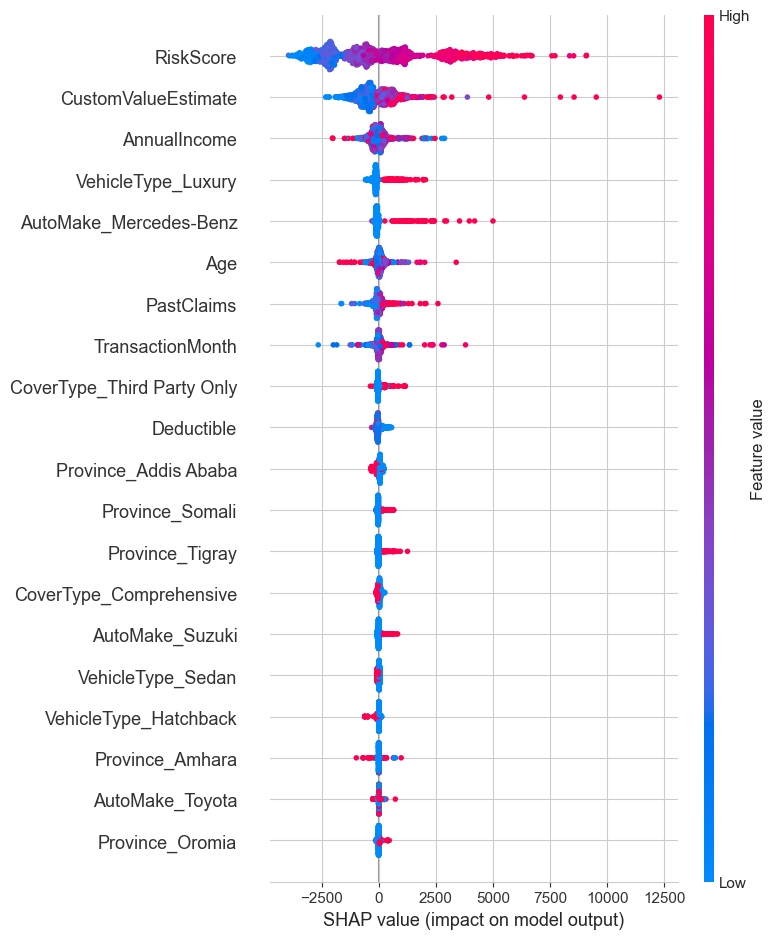

In [34]:
shap.summary_plot(
    shap_values,
    X_train_processed,
    feature_names=all_feature_names
)

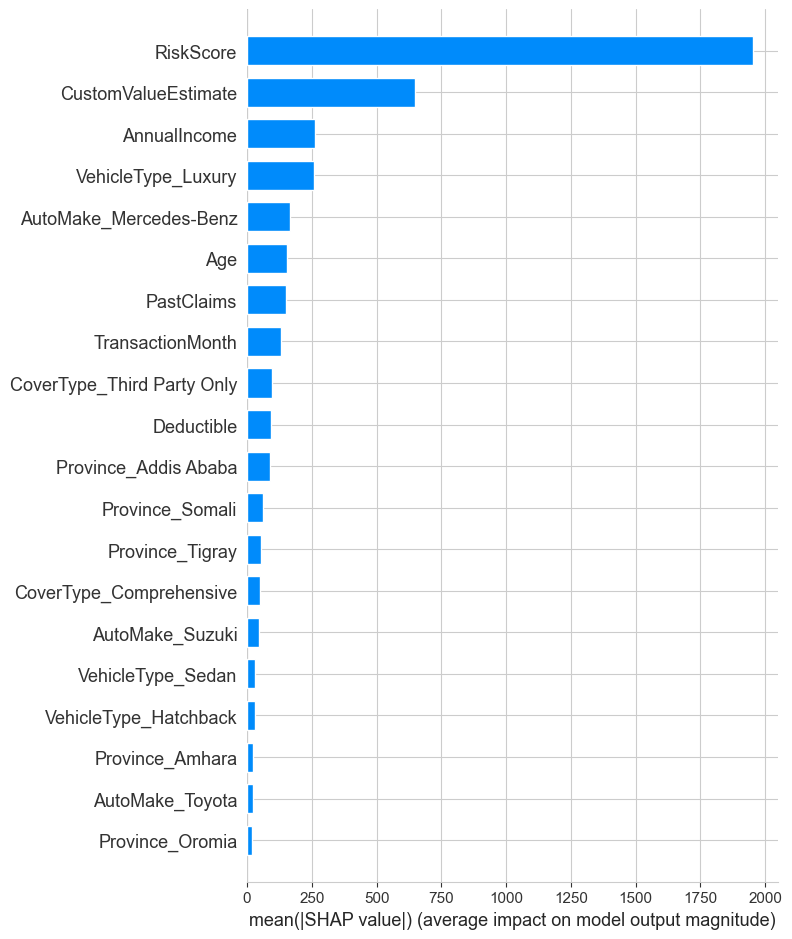

In [35]:
shap.summary_plot(
    shap_values,
    X_train_processed,
    feature_names=all_feature_names,
    plot_type="bar"
)

In [36]:
importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": np.abs(shap_values.values).mean(axis=0)
})

top_features = (
    importance_df
    .sort_values(by="Importance", ascending=False)
    .head(10)
)

top_features

,Feature,Importance
22,RiskScore,1953.236816
25,CustomValueEstimate,648.378845
21,AnnualIncome,263.912109
8,VehicleType_Luxury,259.850891
17,AutoMake_Mercedes-Benz,166.287338
20,Age,153.949341
24,PastClaims,149.706497
26,TransactionMonth,132.281281
13,CoverType_Third Party Only,94.231857
23,Deductible,93.063492


The SHAP feature importance analysis identified the most influential variables affecting predicted claim severity.

The top-ranked features contribute most strongly to the model’s pricing and risk estimation decisions.

# Business Interpretation of SHAP Results

The SHAP analysis provides several important business insights into insurance risk behavior.

### Key Findings

#### 1. RiskScore
RiskScore emerged as one of the strongest predictors of claim severity. Policies associated with higher risk scores consistently produced larger predicted claim amounts. This suggests that customer risk profiling should play a central role in premium calculation.

#### 2. CustomValueEstimate
Vehicles with higher estimated values generated significantly larger claim predictions. Expensive vehicles likely involve higher repair and replacement costs, supporting value-adjusted premium pricing.

#### 3. PastClaims
Customers with previous claim history exhibited elevated future claim severity. This confirms that historical claims behavior is a strong indicator of future insurance risk.

#### 4. Deductible
Policies with lower deductibles tended to produce larger predicted claims. Customers with smaller out-of-pocket responsibilities may be more likely to submit higher-cost claims.

#### 5. VehicleType
Certain vehicle categories contributed disproportionately to claim severity. This indicates that vehicle-specific underwriting adjustments may improve profitability.

#### 6. Province
Geographic location significantly influenced predicted claims. Some provinces consistently produced higher expected losses, suggesting regional premium differentiation may be appropriate.

#### 7. AnnualIncome
Income level also influenced risk behavior. Differences in income may affect vehicle usage patterns, repair choices, and claim frequency.

### Business Implications

The SHAP analysis demonstrates that insurance risk is driven by a combination of:
- customer characteristics,
- geographic factors,
- vehicle attributes,
- and historical claims behavior.

These insights provide quantitative evidence for implementing dynamic, risk-adjusted pricing strategies that better align premiums with expected financial exposure.